**Initialisation**

**Imports**

In [ ]:
!pip install fasteda
!pip install cufflinks
!pip install plotly_express
!pip install scikit-learn
!pip install transformers -U -q
!pip install sentencepiece

  Preparing metadata (setup.py) ... done
  Created wheel for fasteda: filename=fasteda-1.0.1-py3-none-any.whl size=4723 sha256=5f27b1bb87f16ad35ba9b7de67af7bc1ace0e686d8c1f0e9ac8d83b4ad1288ce
  Stored in directory: /root/.cache/pip/wheels/ed/08/72/0d0ec0d3927d227b38ce9542ec3fa6b975c2e17ad0d046dcee
Successfully built fasteda
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 48.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 33.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 100.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 36.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.3 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import numpy as np
from fasteda import fast_eda
import cufflinks as cf
from collections import Counter
import plotly_express as pe
import re
import tensorflow as tf
from string import digits
import string
from sklearn.model_selection import train_test_split
from keras.layers import Input, LSTM, Embedding, Dense
from keras.models import Model
from sklearn.utils import shuffle

**EDA**

**Dataframe Head**

In [ ]:
path = "/content/Hindi_English_Truncated_Corpus.csv"
df = pd.read_csv(path)

In [ ]:
df.head()

,source,english_sentence,hindi_sentence
0,ted,politicians do not have permission to do what ...,"राजनीतिज्ञों के पास जो कार्य करना चाहिए, वह कर..."
1,ted,"I'd like to tell you about one such child,",मई आपको ऐसे ही एक बच्चे के बारे में बताना चाहू...
2,indic2012,This percentage is even greater than the perce...,यह प्रतिशत भारत में हिन्दुओं प्रतिशत से अधिक है।
3,ted,what we really mean is that they're bad at not...,हम ये नहीं कहना चाहते कि वो ध्यान नहीं दे पाते
4,indic2012,.The ending portion of these Vedas is called U...,इन्हीं वेदों का अंतिम भाग उपनिषद कहलाता है।


**Dataframe Tail**

In [ ]:
df.tail()

,source,english_sentence,hindi_sentence
12800,tides,"Before your next appointment , you can write s...",आपके अगली बार मिलने के समय से पहले आप को नीचे ...
12801,indic2012,83. This desert city of Rajasthan is famous fo...,83. राजस्थान का यह रेगिस्तानी शहर इसके आकर्षणो...
12802,indic2012,Used Surah,प्रयुक्त सूरा
12803,tides,The railway contracts were made when the excha...,रेलवे के अनुबंध तब किये गये जब विनिमय की दर एक...
12804,tides,Different varieties of feeds during t,NaN


**Dataframe Info**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12805 entries, 0 to 12804
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   source            12805 non-null  object
 1   english_sentence  12805 non-null  object
 2   hindi_sentence    12804 non-null  object
dtypes: object(3)
memory usage: 300.2+ KB


Dataframe Missing Values

In [ ]:
df.isna().sum()

source              0
english_sentence    0
hindi_sentence      1
dtype: int64

Dropping Missing Records

In [ ]:
df = df.dropna()

In [ ]:
df.isna().sum()

source              0
english_sentence    0
hindi_sentence      0
dtype: int64

Dataframe Description

In [ ]:
df.describe()

,source,english_sentence,hindi_sentence
count,12804,12804,12804
unique,3,12624,12084
top,tides,(Laughter),(हँसी)
freq,5084,68,26


Tokens and Char Count

In [ ]:
cf.set_config_file(offline=True)
df["eng_char_count"] = df["english_sentence"].str.len()
df["hindi_char_count"] = df["hindi_sentence"].str.len()
df["hindi_tok_count"] = df["hindi_sentence"].str.split(" ").str.len()
df["eng_tok_count"] = df["english_sentence"].str.split(" ").str.len()

In [ ]:
tot_eng_sen = ""
for eng_sent in df["english_sentence"].tolist():
    tot_eng_sen += eng_sent + " "

Counter(tot_eng_sen.split(" ")).most_common(10)

[('the', 11778),
 ('of', 7686),
 ('and', 5540),
 (',', 5411),
 ('.', 5176),
 ('to', 4777),
 ('in', 4143),
 ('a', 3499),
 ('is', 2945),
 ('that', 1746)]

In [ ]:
tot_hindi_sen = ""
for hin_sent in df["hindi_sentence"].tolist():
    tot_hindi_sen += hin_sent + " "

Counter(tot_hindi_sen.split(" ")).most_common(10)

[('के', 8879),
 ('में', 6313),
 ('की', 5006),
 ('है', 4890),
 ('.', 4875),
 ('और', 4766),
 ('से', 3940),
 (',', 3352),
 ('का', 3262),
 ('को', 3237)]

Fast EDA

DataFrame Head:


,source,eng_char_count,hindi_char_count,hindi_tok_count,eng_tok_count
0,ted,63,68,14,12
1,ted,42,50,11,9
2,indic2012,61,48,9,10


DataFrame Tail:


,source,eng_char_count,hindi_char_count,hindi_tok_count,eng_tok_count
12801,indic2012,112,113,20,18
12802,indic2012,10,13,2,2
12803,tides,65,66,16,13


----------------------------------------------------------------------------------------------------
Missing values:


,0


----------------------------------------------------------------------------------------------------
Shape of DataFrame:

(12804, 5)

----------------------------------------------------------------------------------------------------
DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12804 entries, 0 to 12803
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   source            12804 non-null  object
 1   eng_char_count    12804 non-null  int64 
 2   hindi_char_count  12804 non-null  int64 
 3   hindi_tok_count   12804 non-null  int64 
 4   eng_tok_count     12804 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 600.2+ KB
----------------------------------------------------------------------------------------------------
Describe DataFrame:



,count,mean,median,std,min,25%,50%,75%,max,skewness,kurtosis
eng_char_count,12804,90.273,65,83.609,1,38,65,119,1296,3.501163,24.995291
hindi_char_count,12804,89.007,64,87.996,2,36,64,116,1526,4.069576,31.227180
hindi_tok_count,12804,18.059,13,17.156,1,8,13,24,314,3.790045,28.743000
eng_tok_count,12804,16.256,12,14.791,1,7,12,22,218,3.186901,20.615666


----------------------------------------------------------------------------------------------------
DataFrame Correlation:



/usr/local/lib/python3.10/dist-packages/fasteda/__init__.py:124: FutureWarning:

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



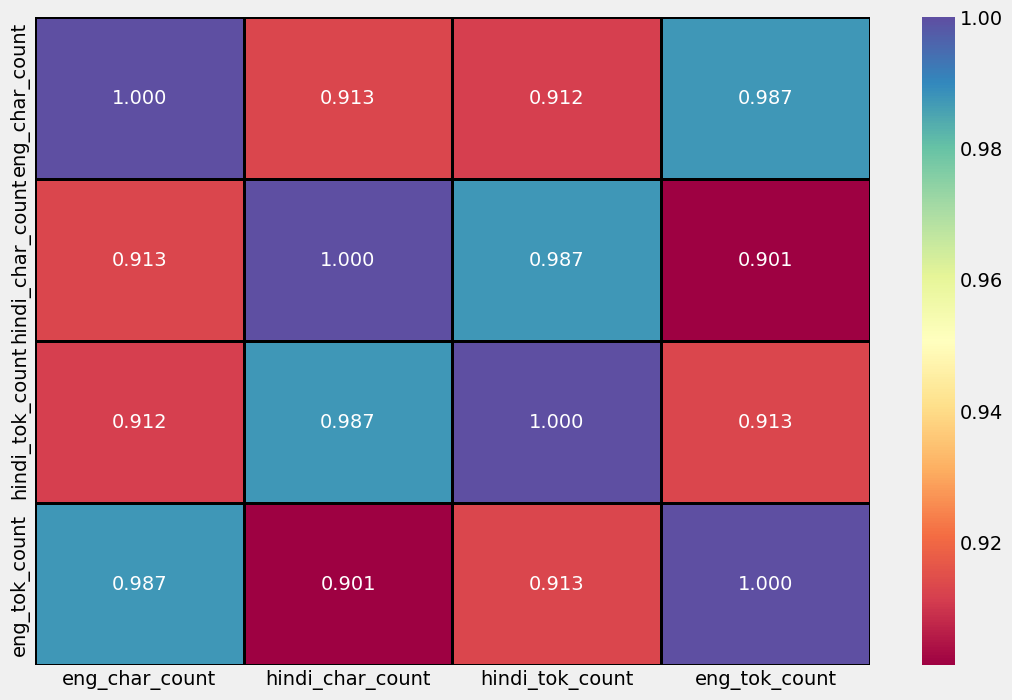

----------------------------------------------------------------------------------------------------
DataFrame Pairplot:



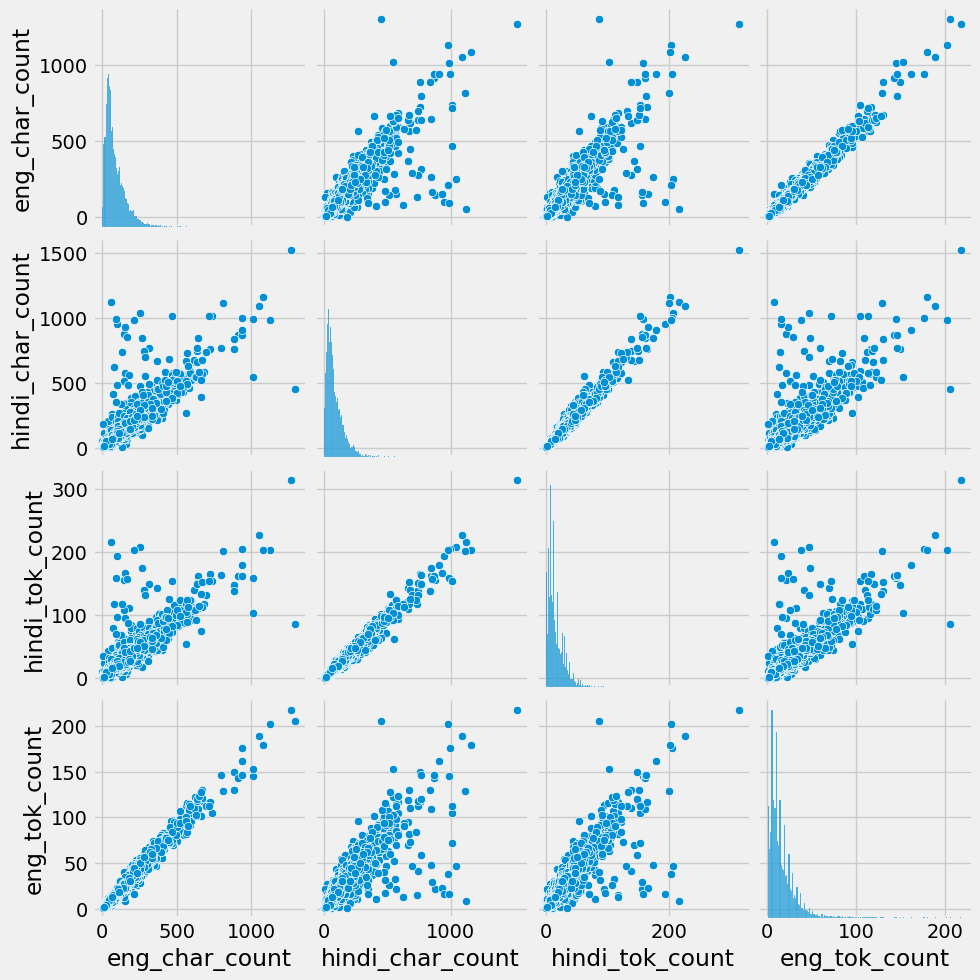

----------------------------------------------------------------------------------------------------
Histogram(s) & Boxplot(s):



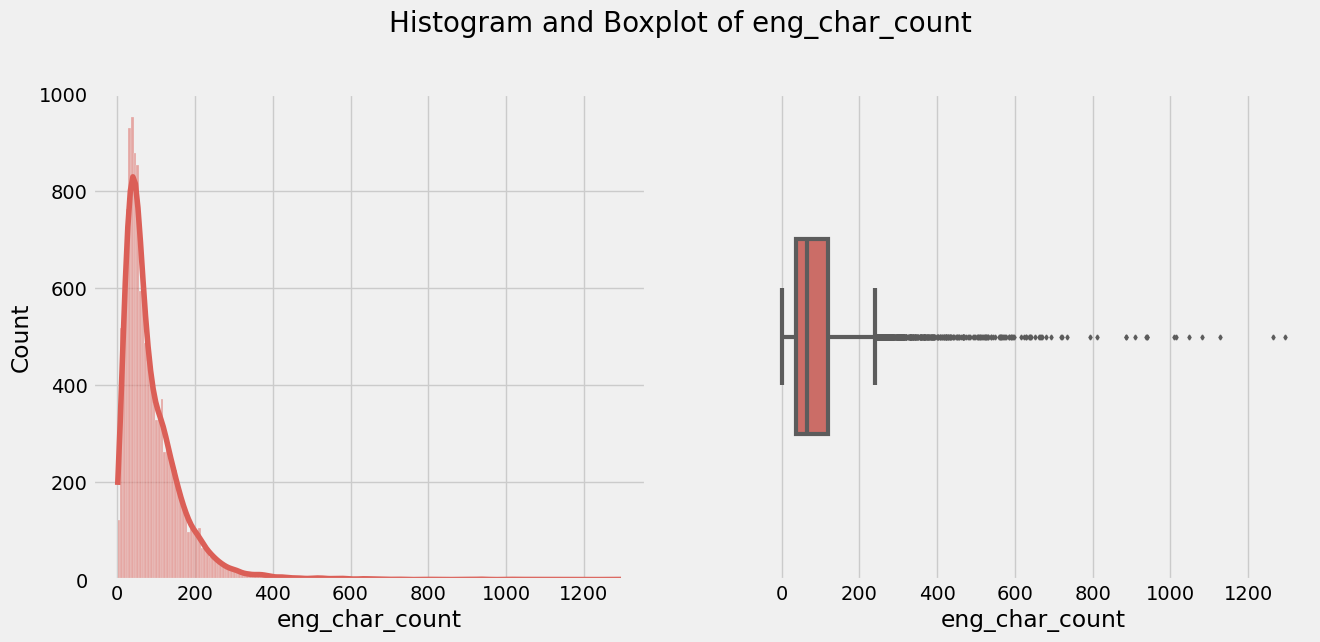

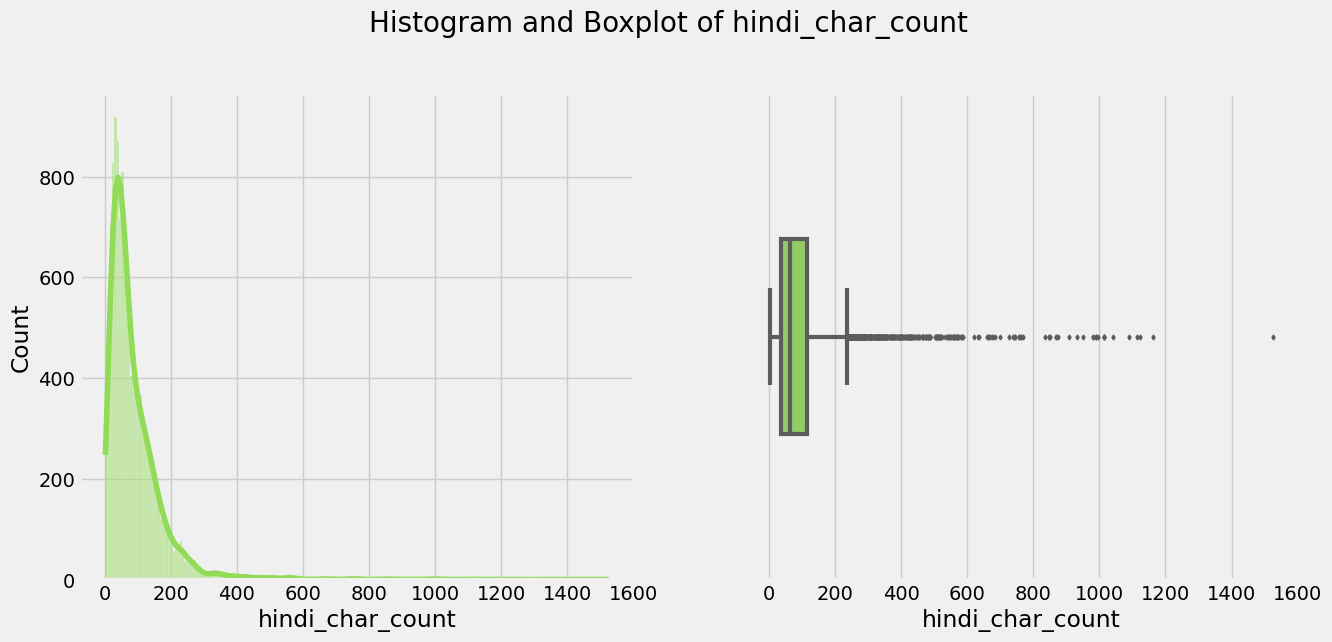

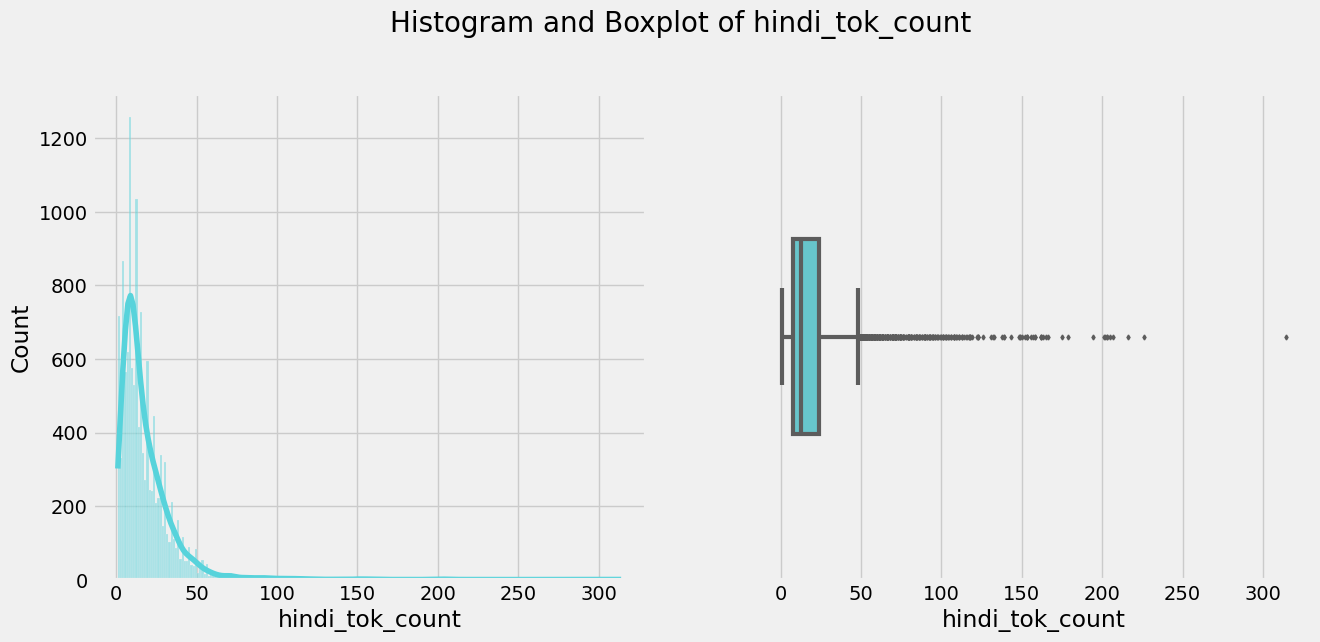

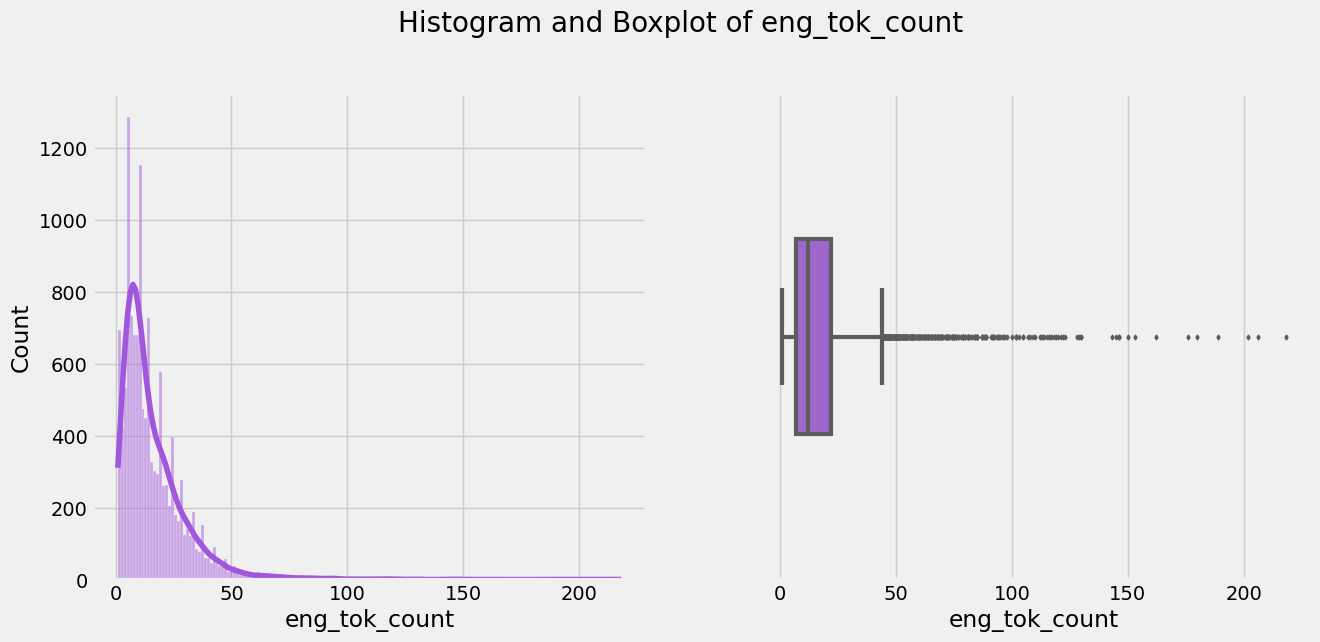

----------------------------------------------------------------------------------------------------
Countplot(s):



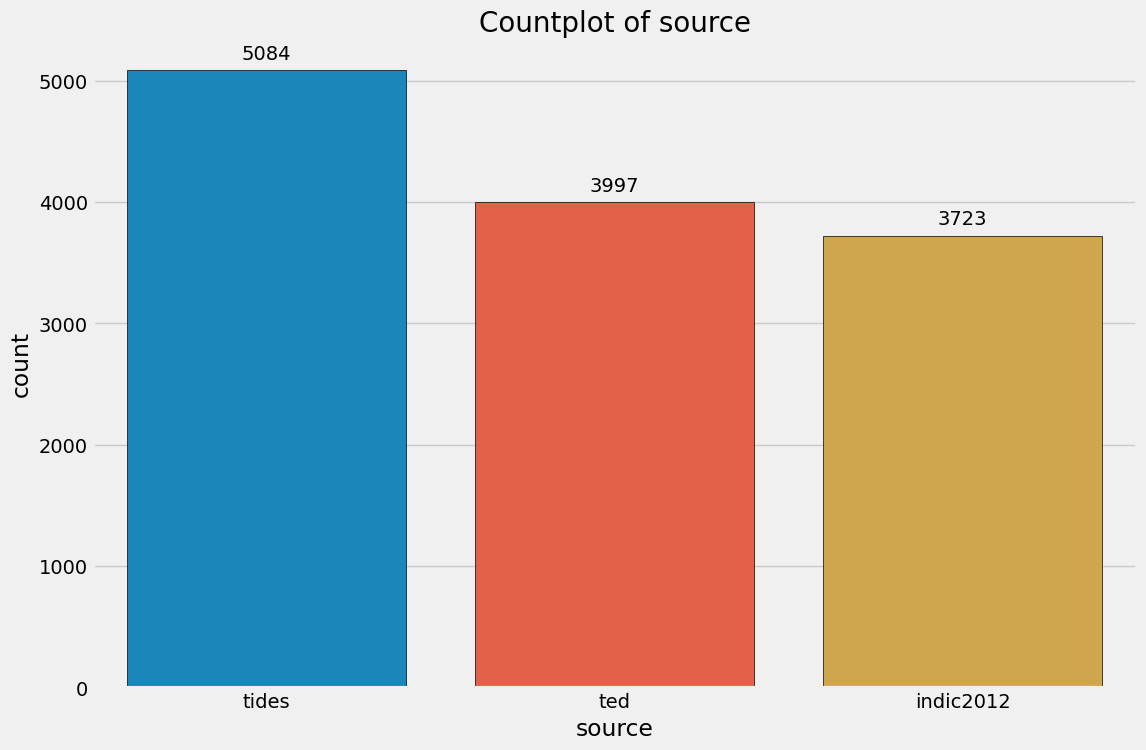

In [ ]:
fast_eda(df[["source", "eng_char_count", 	"hindi_char_count", 	"hindi_tok_count", 	"eng_tok_count",]])

**Discussing Approaches**

In [ ]:
df

,source,english_sentence,hindi_sentence,eng_char_count,hindi_char_count,hindi_tok_count,eng_tok_count
0,ted,politicians do not have permission to do what ...,"राजनीतिज्ञों के पास जो कार्य करना चाहिए, वह कर...",63,68,14,12
1,ted,"I'd like to tell you about one such child,",मई आपको ऐसे ही एक बच्चे के बारे में बताना चाहू...,42,50,11,9
2,indic2012,This percentage is even greater than the perce...,यह प्रतिशत भारत में हिन्दुओं प्रतिशत से अधिक है।,61,48,9,10
3,ted,what we really mean is that they're bad at not...,हम ये नहीं कहना चाहते कि वो ध्यान नहीं दे पाते,64,46,11,12
4,indic2012,.The ending portion of these Vedas is called U...,इन्हीं वेदों का अंतिम भाग उपनिषद कहलाता है।,55,43,8,9
...,...,...,...,...,...,...,...
12799,ted,Because their teachers say,उनके अध्यापक बताते हैं ऐसा इसलिए होता है क्योंकि,26,48,9,4
12800,tides,"Before your next appointment , you can write s...",आपके अगली बार मिलने के समय से पहले आप को नीचे ...,75,75,18,15
12801,indic2012,83. This desert city of Rajasthan is famous fo...,83. राजस्थान का यह रेगिस्तानी शहर इसके आकर्षणो...,112,113,20,18
12802,indic2012,Used Surah,प्रयुक्त सूरा,10,13,2,2


**Pre Processing**

In [ ]:
df=df[df['source']=='ted']

In [ ]:
df.english_sentence = df.english_sentence.apply(lambda x: x.lower())
df.hindi_sentence = df.hindi_sentence.apply(lambda x: x.lower())

In [ ]:
import re
df.english_sentence = df.english_sentence.apply(lambda x: re.sub("'", '', x)).apply(lambda x: re.sub(",", ' ', x))
df.hindi_sentence = df.hindi_sentence.apply(lambda x: re.sub("'", '', x)).apply(lambda x: re.sub(",", ' ', x))

In [ ]:
df['english_sentence']=df['english_sentence'].apply(lambda x: re.sub("'", '', x))
df['hindi_sentence']=df['hindi_sentence'].apply(lambda x: re.sub("'", '', x))

In [ ]:
exclude = set(string.punctuation)
df['english_sentence']=df['english_sentence'].apply(lambda x: ''.join(ch for ch in x if ch not in exclude))
df['hindi_sentence']=df['hindi_sentence'].apply(lambda x: ''.join(ch for ch in x if ch not in exclude))

In [ ]:
remove_digits = str.maketrans('', '', digits)
df['english_sentence']=df['english_sentence'].apply(lambda x: x.translate(remove_digits))
df['hindi_sentence']=df['hindi_sentence'].apply(lambda x: x.translate(remove_digits))
df['hindi_sentence'] = df['hindi_sentence'].apply(lambda x: re.sub("[२३०८१५७९४६]", "", x))

df['english_sentence']=df['english_sentence'].apply(lambda x: x.strip())
df['hindi_sentence']=df['hindi_sentence'].apply(lambda x: x.strip())
df['english_sentence']=df['english_sentence'].apply(lambda x: re.sub(" +", " ", x))
df['hindi_sentence']=df['hindi_sentence'].apply(lambda x: re.sub(" +", " ", x))

In [ ]:
df.sample(5)

,source,english_sentence,hindi_sentence,eng_char_count,hindi_char_count,hindi_tok_count,eng_tok_count
11563,ted,it doesnt matter whether you talk to people,इससे कोई फर्क नहीं पड़ता कि आप उन लोगों से बात...,44,51,12,8
4332,ted,at least she got it close,कम से कम वह इसके करीब है।,26,25,7,6
6704,ted,“well you choose” and i said “no no im learnin...,“आप ही बता दीजिये।” और मैने कहा “नहीं नहीं मै ...,64,75,16,12
366,ted,prostate tumor activity is shown in red you can,प्रोस्टेट ट्यूमर गतिविधि लाल रंग से दिखाई गई है,49,49,10,10
3406,ted,that are not going to learn to talk and theyre...,जो कि कभी बोलना नही सीखेंगे और कभी काम नही कर ...,72,52,12,15


In [ ]:
df['hindi_sentence'] = df['hindi_sentence'].apply(lambda x :'START_ ' + x + ' _END')

In [ ]:
df

,source,english_sentence,hindi_sentence,eng_char_count,hindi_char_count,hindi_tok_count,eng_tok_count
0,ted,politicians do not have permission to do what ...,START_ राजनीतिज्ञों के पास जो कार्य करना चाहिए...,63,68,14,12
1,ted,id like to tell you about one such child,START_ मई आपको ऐसे ही एक बच्चे के बारे में बता...,42,50,11,9
3,ted,what we really mean is that theyre bad at not ...,START_ हम ये नहीं कहना चाहते कि वो ध्यान नहीं ...,64,46,11,12
7,ted,and who are we to say even that they are wrong,START_ और हम होते कौन हैं यह कहने भी वाले कि व...,48,48,13,11
13,ted,so there is some sort of justice,START_ तो वहाँ न्याय है _END,32,16,4,7
...,...,...,...,...,...,...,...
12788,ted,generate their own ideas,START_ नए विचार खुद उत्पन्न करें” _END,25,27,5,4
12791,ted,he simply slipped outside pulled down his seal...,START_ वे सरलता से बाहर निकलते और _END,60,26,6,9
12793,ted,what do you need to hear go home to your wife,START_ आप क्या सुनना चाहते है घर में पत्नी के ...,47,50,11,11
12798,ted,and this is before the internet got really big,START_ इंटरनेट तब बहुत बडा नही हुआ था _END,47,30,7,9


In [ ]:
all_eng_words=set()
for eng in df['english_sentence']:
    for word in eng.split():
        if word not in all_eng_words:
            all_eng_words.add(word)

all_hindi_words=set()
for hin in df['hindi_sentence']:
    for word in hin.split():
        if word not in all_hindi_words:
            all_hindi_words.add(word)

In [ ]:
df['length_eng_sentence']=df['english_sentence'].apply(lambda x:len(x.split(" ")))
df['length_hin_sentence']=df['hindi_sentence'].apply(lambda x:len(x.split(" ")))

In [ ]:
df.head()

,source,english_sentence,hindi_sentence,eng_char_count,hindi_char_count,hindi_tok_count,eng_tok_count,length_eng_sentence,length_hin_sentence
0,ted,politicians do not have permission to do what ...,START_ राजनीतिज्ञों के पास जो कार्य करना चाहिए...,63,68,14,12,12,15
1,ted,id like to tell you about one such child,START_ मई आपको ऐसे ही एक बच्चे के बारे में बता...,42,50,11,9,9,13
3,ted,what we really mean is that theyre bad at not ...,START_ हम ये नहीं कहना चाहते कि वो ध्यान नहीं ...,64,46,11,12,12,13
7,ted,and who are we to say even that they are wrong,START_ और हम होते कौन हैं यह कहने भी वाले कि व...,48,48,13,11,11,15
13,ted,so there is some sort of justice,START_ तो वहाँ न्याय है _END,32,16,4,7,7,6


In [ ]:
print('length of english words: ', len(all_eng_words))
print('length of hindi words: ', len(all_hindi_words))

length of english words:  5095
length of hindi words:  5961


In [ ]:
input_words = sorted(list(all_eng_words))
target_words = sorted(list(all_hindi_words))
num_encoder_tokens = len(all_eng_words)
num_decoder_tokens = len(all_hindi_words)
num_encoder_tokens, num_decoder_tokens

(5095, 5961)

In [ ]:
num_decoder_tokens += 1 #for zero padding

In [ ]:
input_token_index = dict([(word, i+1) for i, word in enumerate(input_words)])
target_token_index = dict([(word, i+1) for i, word in enumerate(target_words)])

In [ ]:
reverse_input_char_index = dict((i, word) for word, i in input_token_index.items())
reverse_target_char_index = dict((i, word) for word, i in target_token_index.items())

In [ ]:
df = shuffle(df)
df.head(10)

,source,english_sentence,hindi_sentence,eng_char_count,hindi_char_count,hindi_tok_count,eng_tok_count,length_eng_sentence,length_hin_sentence
3182,ted,so what happened on this day,START_ सो इस दिन क्या हुआ _END,29,19,5,6,6,7
603,ted,now religions have a much saner attitude to art,START_ धर्मों का कला के प्रति काफ़ी साफ़ नज़रि...,48,45,9,9,9,11
9636,ted,and what were learning,START_ और जो हम सीख रहे हैं _END,23,20,6,4,4,8
1803,ted,of a map just by pinching all present,START_ सिर्फ़ उन सबको दबाने से। _END,38,24,5,8,8,7
487,ted,his holiness the karmapa tomorrow is my talk,START_ परमपावन करमापा कल मेरा व्याख्यान है _END,46,38,7,8,8,8
7635,ted,what i mean is with the profits from the first...,START_ मेरा मतलब है कि पहले चौथाई एकड के मुनाफ...,60,44,10,12,12,12
2136,ted,and that is that people,START_ और ये वो विचार है _END,23,17,5,5,5,7
3425,ted,dont forget the air conditioning and the cable...,START_ वातानुकूलन और काल के तारो को मत भूलिए _END,54,38,8,9,9,10
4465,ted,and i put them together so that in each pair o...,START_ और मैंने प्रश्नों को एक साथ रख दिया जिस...,57,72,15,12,12,17
122,ted,where the time the website,START_ कहाँ कब वेब्साइट। _END,29,20,4,5,5,5


In [ ]:
# getting maximum sentence length of english sentences
length_list = []
for l in df.english_sentence:
    length_list.append(len(l.split(' ')))

max_input_length = np.max(length_list)
print('max_input_length: ', max_input_length)

max_input_length:  18


In [ ]:
 #getting maximum sentence length of Hindi sentences
length_list = []
for l in df.hindi_sentence:
    length_list.append(len(l.split(' ')))

max_output_length = np.max(length_list)
print('max_output_length: ', max_output_length)

max_output_length:  32


In [ ]:
df_=df[df['length_eng_sentence']<=20]
df_=df[df['length_hin_sentence']<=20]

In [ ]:
print("maximum length of Hindi Sentence ",max(df['length_hin_sentence']))
print("maximum length of English Sentence ",max(df['length_eng_sentence']))

maximum length of Hindi Sentence  32
maximum length of English Sentence  18


In [ ]:
x, y = df['english_sentence'], df['hindi_sentence']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.5,random_state=42)
x_train.shape, x_test.shape

((1998,), (1999,))

In [ ]:
x_train

9946     now things changed when i discovered african b...
4992                                      a student missed
1146                                            “oh jesus”
6634     when i started you thought “how beautiful that...
7071        have all got to assemble on the ross ice shelf
                               ...                        
11067                                      or the highline
8233                               and i painted for years
8589     and even at this point i started to move away ...
4214                  so i decided if i couldnt run myself
12143         they were found in present day iraq and iran
Name: english_sentence, Length: 1998, dtype: object

In [ ]:
y_train

9946     START_ लेकिन जब मैंने अफ़्रीकी पुस्तकें पढ़ना ...
4992                START_ एक बच्चे ने गलत जवाब दिये। _END
1146                               START_ “हे भगवान्” _END
6634     START_ जब मैंने बजाना शुरू किया तो आपने सोचा “...
7071     START_ सभी को रॉस हिम परत पर एकत्र होना पड़ता ...
                               ...                        
11067                    START_ हिसाब से बदल सकती हूँ _END
8233                   START_ और सालो तक चित्रकारी की _END
8589     START_ और इस मोड़ पर भी मैं मानवपन की नक़ल करन...
4214     START_ इसलिए मैंने तय कर लिया अगर खुद नही भाग ...
12143     START_ वे वर्तमान इराक और ईरान में मिले थे। _END
Name: hindi_sentence, Length: 1998, dtype: object

In [ ]:
x_train.to_pickle('x_train.pkl')
x_test.to_pickle('x_test.pkl')

**Implementation Using Transformer**

In [ ]:
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast
import tensorflow as tf

In [ ]:
#Training
model = MBartForConditionalGeneration.from_pretrained("facebook/mbart-large-50-one-to-many-mmt")
tokenizer = MBart50TokenizerFast.from_pretrained("facebook/mbart-large-50-one-to-many-mmt", src_lang="en_XX")

In [ ]:
def translate(in_text):
    model_inputs = tokenizer(in_text, return_tensors="pt")

    generated_tokens = model.generate(
        **model_inputs,
        forced_bos_token_id=tokenizer.lang_code_to_id["hi_IN"]
    )
    translation = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)
    return translation

In [ ]:
temp_df  = df["english_sentence"].head(10)
res = temp_df.apply(translate)

In [ ]:
print(f"English : {temp_df.iloc[0]}\nTranslated Hindi : {res.iloc[0][0]}\nOriginal Hindi : {df['hindi_sentence'].iloc[0].replace('START_', '').replace('_END', '')}")

English : so what happened on this day
Translated Hindi : तो इस दिन क्या हुआ
Original Hindi :  सो इस दिन क्या हुआ 


In [ ]:
del model
del tokenizer

**Implementation Using Encoder & Decoder**

In [ ]:
def generate_batch(X = x_train, y = y_train, batch_size = 128):
    while True:
        for j in range(0, len(X), batch_size):
            encoder_input_data = np.zeros((batch_size, max_input_length),dtype='float32')
            decoder_input_data = np.zeros((batch_size, max_output_length),dtype='float32')
            decoder_target_data = np.zeros((batch_size, max_output_length, num_decoder_tokens),dtype='float32')
            for i, (input_text, target_text) in enumerate(zip(X[j:j+batch_size], y[j:j+batch_size])):
                for t, word in enumerate(input_text.split()):
                    encoder_input_data[i, t] = input_token_index[word]
                for t, word in enumerate(target_text.split()):
                    if t<len(target_text.split())-1:
                        decoder_input_data[i, t] = target_token_index[word]
                    if t>0:
                        decoder_target_data[i, t - 1, target_token_index[word]] = 1.
            yield([encoder_input_data, decoder_input_data], decoder_target_data)

In [ ]:
latent_dim=300

In [ ]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model

**Defining Encoder & Decoder**

In [ ]:
encoder_inputs = Input(shape=(None,))
enc_emb =  Embedding(num_encoder_tokens, latent_dim, mask_zero = True)(encoder_inputs)
encoder_lstm = LSTM(latent_dim, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)
# We discard `encoder_outputs` and only keep the states.
encoder_states = [state_h, state_c]

In [ ]:
# Set up the decoder, using `encoder_states` as initial state.
decoder_inputs = Input(shape=(None,))
dec_emb_layer = Embedding(num_decoder_tokens, latent_dim, mask_zero = True)
dec_emb = dec_emb_layer(decoder_inputs)
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb,
                                     initial_state=encoder_states)
decoder_dense = Dense(num_decoder_tokens, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

In [ ]:
# Define the model that will turn
# `encoder_input_data` & `decoder_input_data` into `decoder_target_data`
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='rmsprop', loss='categorical_crossentropy')

**Model Summary**

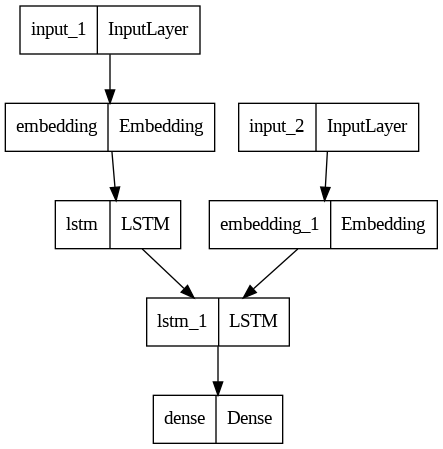

In [ ]:
plot_model(model)

In [ ]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, None)]               0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, None)]               0         []                            
                                                                                                  
 embedding (Embedding)       (None, None, 300)            1528500   ['input_1[0][0]']             
                                                                                                  
 embedding_1 (Embedding)     (None, None, 300)            1788600   ['input_2[0][0]']             
                                                                                              

In [ ]:
train_samples = len(x_train)
val_samples = len(x_test)
batch_size = 128
epochs = 100

**model training**

In [ ]:
model.fit(generate_batch(x_train, y_train, batch_size = batch_size),
                    steps_per_epoch = train_samples//batch_size,
                    validation_data = generate_batch(x_test, y_test, batch_size = batch_size),
                    validation_steps = val_samples//batch_size)

 9/15 [=================>............] - ETA: 15s - loss: 8.3929

InvalidArgumentError: ignored

In [ ]:
model.save_weights('nmt_weights.h5')

**Inferencing**

In [ ]:
encoder_model = Model(encoder_inputs, encoder_states)

# Decoder setup
# Below tensors will hold the states of the previous time step
decoder_state_input_h = Input(shape=(latent_dim,))
decoder_state_input_c = Input(shape=(latent_dim,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

dec_emb2= dec_emb_layer(decoder_inputs) # Get the embeddings of the decoder sequence

# To predict the next word in the sequence, set the initial states to the states from the previous time step
decoder_outputs2, state_h2, state_c2 = decoder_lstm(dec_emb2, initial_state=decoder_states_inputs)
decoder_states2 = [state_h2, state_c2]
decoder_outputs2 = decoder_dense(decoder_outputs2) # A dense softmax layer to generate prob dist. over the target vocabulary

# Final decoder model
decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs2] + decoder_states2)

In [ ]:
def decode_sequence(input_seq):
    # Encode the input as state vectors.
    states_value = encoder_model.predict(input_seq)
    # Generate empty target sequence of length 1.
    target_seq = np.zeros((1,1))
    # Populate the first character of target sequence with the start character.
    target_seq[0, 0] = target_token_index['START_']

    # Sampling loop for a batch of sequences
    # (to simplify, here we assume a batch of size 1).
    stop_condition = False
    decoded_sentence = ''
    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value)

        # Sample a token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_char = reverse_target_char_index[sampled_token_index]
        decoded_sentence += ' '+sampled_char

        # Exit condition: either hit max length
        # or find stop character.
        if (sampled_char == '_END' or
           len(decoded_sentence) > 50):
            stop_condition = True

        # Update the target sequence (of length 1).
        target_seq = np.zeros((1,1))
        target_seq[0, 0] = sampled_token_index

        # Update states
        states_value = [h, c]

    return decoded_sentence

In [ ]:
train_gen = generate_batch(x_train, y_train, batch_size = 1)
k=-1

**tested output**

In [ ]:
k+=1
(input_seq, actual_output), _ = next(train_gen)
decoded_sentence = decode_sequence(input_seq)
print('Input English sentence:', x_train[k:k+1].values[0])
print('Actual Hindi Translation:', y_train[k:k+1].values[0][6:-4])
print('Predicted Hindi Translation:', decoded_sentence[:-4])

1/1 [==============================] - 3s 3s/step
Input English sentence: now things changed when i discovered african books
Actual Hindi Translation:  लेकिन जब मैंने अफ़्रीकी पुस्तकें पढ़ना शुरु किया तो चीजें बदल गईं 
Predicted Hindi Translation:  


In [ ]:
k+=1
(input_seq, actual_output), _ = next(train_gen)
decoded_sentence = decode_sequence(input_seq)
print('Input English sentence:', x_train[k:k+1].values[0])
print('Actual Hindi Translation:', y_train[k:k+1].values[0][6:-4])
print('Predicted Hindi Translation:', decoded_sentence[:-4])

1/1 [==============================] - 0s 27ms/step
Input English sentence: a student missed
Actual Hindi Translation:  एक बच्चे ने गलत जवाब दिये। 
Predicted Hindi Translation:  


In [ ]:
k+=1
(input_seq, actual_output), _ = next(train_gen)
decoded_sentence = decode_sequence(input_seq)
print('Input English sentence:', x_train[k:k+1].values[0])
print('Actual Hindi Translation:', y_train[k:k+1].values[0][6:-4])
print('Predicted Hindi Translation:', decoded_sentence[:-4])

1/1 [==============================] - 0s 62ms/step
Input English sentence: “oh jesus”
Actual Hindi Translation:  “हे भगवान्” 
Predicted Hindi Translation:  


In [ ]:
k+=1
(input_seq, actual_output), _ = next(train_gen)
decoded_sentence = decode_sequence(input_seq)
print('Input English sentence:', x_train[k:k+1].values[0])
print('Actual Hindi Translation:', y_train[k:k+1].values[0][6:-4])
print('Predicted Hindi Translation:', decoded_sentence[:-4])

1/1 [==============================] - 0s 107ms/step
Input English sentence: when i started you thought “how beautiful that sounds”
Actual Hindi Translation:  जब मैंने बजाना शुरू किया तो आपने सोचा “कितना सुन्दर संगीत है” 
Predicted Hindi Translation:  
